### Coding Question: Image Classification Neural Network

Using the dataset provided below, design and implement a **Neural Network for multi-class image classification**.

**Dataset:** [Nepali Numbers and Letters Dataset](https://github.com/ShaileshAdhikari/nepali-text-classification/blob/main/images.rar)

Your implementation should include:

1. **Data Preparation**

   * Load, preprocess, resize, normalize, and split the dataset into train/validation/test sets.

2. **Neural Network**

3. **Hyperparameter Tuning**

4. **Evaluation**
   Evaluate the final model using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Macro/Weighted F1
   * Confusion Matrix

5. **Performance Analysis**

**Deliverable:** Complete, reproducible code with a final report comparing the experimented configurations and their performance.


In [3]:
import os
import random
import time
import warnings
import unrar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import set_random_seed

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_random_seed(SEED)

## Data Preparation

In [4]:
if not os.path.isdir("./data/images"):
    from unrar.cffi import rarfile

    rf = rarfile.RarFile("./data/images.rar")
    for info in rf.infolist():
        if info.is_dir():
            continue
        out = os.path.join("../data", info.filename)
        os.makedirs(os.path.dirname(out), exist_ok=True)
        with open(out, "wb") as f:
            f.write(rf.read(info))

In [5]:
DATA_DIR = "../data/images"
IMG_SIZE = 32

class_names = sorted(os.listdir(DATA_DIR), key=lambda c: (not c.isdigit(), c))
class_names

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'ba', 'pa']

In [6]:
X, y = [], []

for label, name in enumerate(class_names):
    for file in sorted(os.listdir(os.path.join(DATA_DIR, name))):
        img = Image.open(os.path.join(DATA_DIR, name, file)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        X.append(np.asarray(img))
        y.append(label)

X = np.array(X)
y = np.array(y)

X.shape, y.shape

((2033, 32, 32, 3), (2033,))

In [7]:
pd.Series(y).map(dict(enumerate(class_names))).value_counts().reindex(class_names)

0      96
1     171
2     176
3     186
4     206
5     194
6     159
7     147
8     135
9     123
ba    206
pa    234
Name: count, dtype: int64

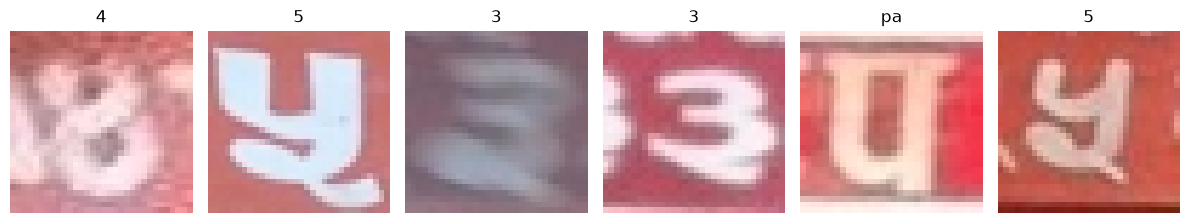

In [8]:
indices = np.random.choice(len(X), 6, replace=False)

fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for ax, i in zip(axes, indices):
    ax.imshow(X[i])
    ax.set_title(class_names[y[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# min-max scaling
X = X / 255

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

X_train.shape, X_val.shape, X_test.shape

((1423, 32, 32, 3), (305, 32, 32, 3), (305, 32, 32, 3))

In [11]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_oh = one_hot_encoder.fit_transform(y_train.reshape(-1, 1))
y_val_oh = one_hot_encoder.transform(y_val.reshape(-1, 1))
y_test_oh = one_hot_encoder.transform(y_test.reshape(-1, 1))

## Model Definition

In [12]:
input_shape = X_train.shape[1:]
input_shape

(32, 32, 3)

In [13]:
def build_model(filters=(6, 16), kernel=5, dense=(100, 50), dropout=0.5, lr=0.001, optimizer='adam'):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(filters=filters[0], kernel_size=(kernel, kernel), strides=(1, 1), padding='valid', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        Conv2D(filters=filters[1], kernel_size=(kernel, kernel), strides=(1, 1), padding='valid', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        Flatten(),

        Dense(dense[0], activation='relu'),
        Dropout(dropout),
        Dense(dense[1], activation='relu'),
        Dense(len(class_names), activation='softmax')
    ])

    opt = {'adam': Adam(lr), 'rmsprop': RMSprop(lr), 'sgd': SGD(lr, momentum=0.9)}[optimizer]

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [14]:
build_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,634 (189.98 KB)

 Trainable params: 48,634 (189.98 KB)

 Non-trainable params: 0 (0.00 B)

## Hyperparameter Tuning

In [ ]:
base = dict(filters=(6, 16), kernel=5, dense=(100, 50), dropout=0.5, lr=0.001, optimizer='adam', batch_size=64)

configs = {
    "C01 baseline": {},
    "C02 lr=0.01": dict(lr=0.01),
    "C03 lr=0.0001": dict(lr=0.0001),
    "C04 SGD": dict(optimizer='sgd', lr=0.01),
    "C05 RMSprop": dict(optimizer='rmsprop'),
    "C06 filters=16/32": dict(filters=(16, 32)),
    "C07 filters=32/64": dict(filters=(32, 64)),
    "C08 kernel=3": dict(kernel=3),
    "C09 dropout=0.0": dict(dropout=0.0),
    "C10 dropout=0.3": dict(dropout=0.3),
    "C11 dense=200/100": dict(dense=(200, 100)),
    "C12 batch=32": dict(batch_size=32),
}

In [16]:
rows = []
histories = {}
models = {}

for name, change in configs.items():
    hp = {**base, **change}
    set_random_seed(SEED)

    model = build_model(filters=hp['filters'], kernel=hp['kernel'], dense=hp['dense'],
                        dropout=hp['dropout'], lr=hp['lr'], optimizer=hp['optimizer'])

    start = time.time()
    history = model.fit(
        X_train, y_train_oh,
        epochs=40,
        batch_size=hp['batch_size'],
        validation_data=(X_val, y_val_oh),
        callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
        verbose=0
    )
    seconds = time.time() - start

    train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)

    rows.append({
        'config': name,
        'params': model.count_params(),
        'epochs': len(history.history['loss']),
        'train_acc': accuracy_score(y_train, train_pred),
        'val_acc': accuracy_score(y_val, val_pred),
        'val_macro_f1': f1_score(y_val, val_pred, average='macro'),
        'val_loss': min(history.history['val_loss']),
        'time_s': round(seconds),
    })
    histories[name] = history.history
    models[name] = model
    print(f"{name:20s} val_acc={rows[-1]['val_acc']:.4f}  val_macro_f1={rows[-1]['val_macro_f1']:.4f}  ({seconds:.0f}s)")

C01 baseline         val_acc=0.9377  val_macro_f1=0.9358  (9s)
C02 lr=0.01          val_acc=0.1148  val_macro_f1=0.0172  (4s)
C03 lr=0.0001        val_acc=0.7803  val_macro_f1=0.7702  (9s)
C04 SGD              val_acc=0.9246  val_macro_f1=0.9215  (8s)
C05 RMSprop          val_acc=0.9213  val_macro_f1=0.9196  (8s)
C06 filters=16/32    val_acc=0.9508  val_macro_f1=0.9500  (10s)
C07 filters=32/64    val_acc=0.9443  val_macro_f1=0.9455  (16s)
C08 kernel=3         val_acc=0.9246  val_macro_f1=0.9202  (6s)
C09 dropout=0.0      val_acc=0.9213  val_macro_f1=0.9199  (7s)
C10 dropout=0.3      val_acc=0.9082  val_macro_f1=0.9046  (6s)
C11 dense=200/100    val_acc=0.9115  val_macro_f1=0.9101  (7s)
C12 batch=32         val_acc=0.9246  val_macro_f1=0.9236  (7s)


In [17]:
results = pd.DataFrame(rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
results.to_csv('tuning_results.csv', index=False)
results.round(4)

,config,params,epochs,train_acc,val_acc,val_macro_f1,val_loss,time_s
0,C06 filters=16/32,99810,40,0.9958,0.9508,0.9500,0.1885,10
1,C07 filters=32/64,219458,40,0.9902,0.9443,0.9455,0.1970,16
2,C01 baseline,48634,40,0.9817,0.9377,0.9358,0.2276,9
3,C12 batch=32,48634,28,0.9754,0.9246,0.9236,0.2567,7
4,C04 SGD,48634,36,0.9649,0.9246,0.9215,0.3062,8
5,C08 kernel=3,64410,37,0.9761,0.9246,0.9202,0.3026,6
6,C09 dropout=0.0,48634,33,0.9726,0.9213,0.9199,0.2654,7
7,C05 RMSprop,48634,40,0.9677,0.9213,0.9196,0.2880,8
8,C11 dense=200/100,104384,29,0.9768,0.9115,0.9101,0.2526,7
9,C10 dropout=0.3,48634,29,0.9691,0.9082,0.9046,0.2589,6


In [18]:
best_name = results.loc[0, 'config']
model = models[best_name]
best_name

'C06 filters=16/32'

<Axes: title={'center': 'Loss vs. Validation Loss (C06 filters=16/32)'}>

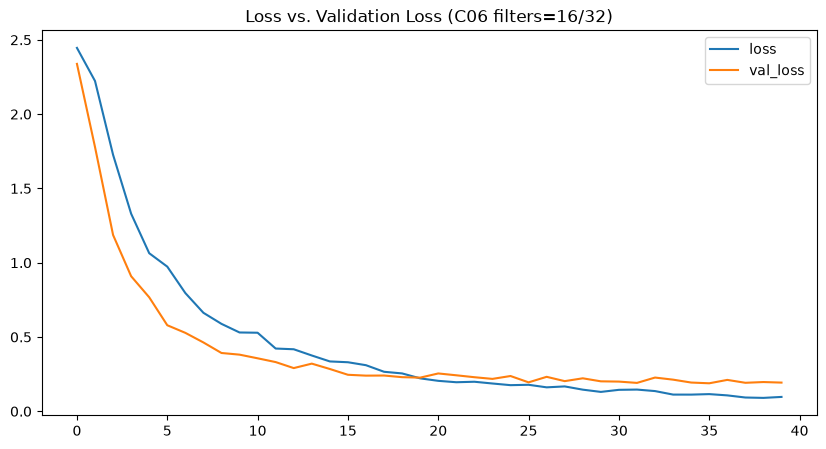

In [19]:
df = pd.DataFrame(histories[best_name])
df[['loss', 'val_loss']].plot(title=f'Loss vs. Validation Loss ({best_name})', figsize=(10, 5))

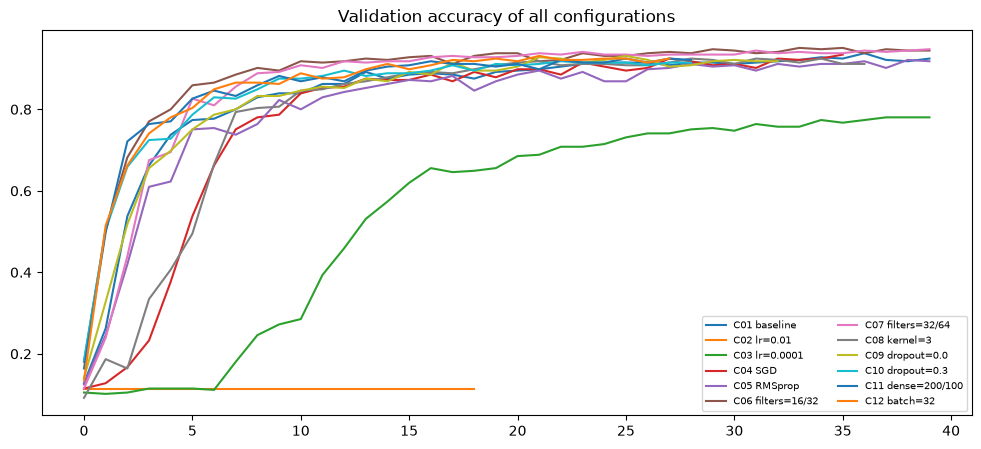

In [20]:
pd.DataFrame({name: pd.Series(h['val_accuracy']) for name, h in histories.items()}).plot(
    title='Validation accuracy of all configurations', figsize=(12, 5), legend=False)
plt.legend(fontsize=7, ncol=2)
plt.show()

## Evaluation

In [21]:
y_pred = np.argmax(model.predict(X_test), axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


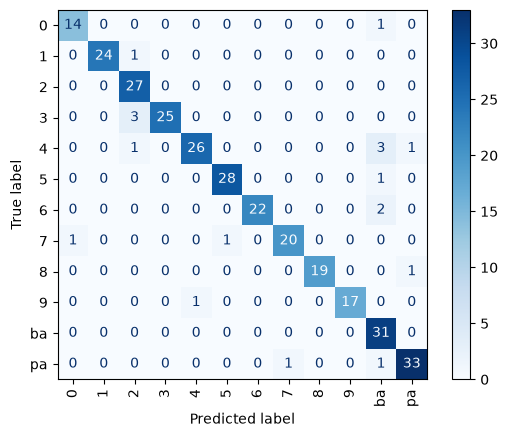

In [22]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=class_names).plot(cmap='Blues', xticks_rotation='vertical')

In [23]:
accuracy = accuracy_score(y_test, y_pred)

recall = recall_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

recall_w = recall_score(y_test, y_pred, average='weighted')
precision_w = precision_score(y_test, y_pred, average='weighted')
f1_w = f1_score(y_test, y_pred, average='weighted')

In [24]:
print(f"Accuracy: {accuracy:.4f}")
print()
print(f"Macro    -> Precision: {precision:.4f}  Recall: {recall:.4f}  F1 Score: {f1:.4f}")
print(f"Weighted -> Precision: {precision_w:.4f}  Recall: {recall_w:.4f}  F1 Score: {f1_w:.4f}")

Accuracy: 0.9377

Macro    -> Precision: 0.9496  Recall: 0.9378  F1 Score: 0.9412
Weighted -> Precision: 0.9450  Recall: 0.9377  F1 Score: 0.9386


In [25]:
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

           0     0.9333    0.9333    0.9333        15
           1     1.0000    0.9600    0.9796        25
           2     0.8438    1.0000    0.9153        27
           3     1.0000    0.8929    0.9434        28
           4     0.9630    0.8387    0.8966        31
           5     0.9655    0.9655    0.9655        29
           6     1.0000    0.9167    0.9565        24
           7     0.9524    0.9091    0.9302        22
           8     1.0000    0.9500    0.9744        20
           9     1.0000    0.9444    0.9714        18
          ba     0.7949    1.0000    0.8857        31
          pa     0.9429    0.9429    0.9429        35

    accuracy                         0.9377       305
   macro avg     0.9496    0.9378    0.9412       305
weighted avg     0.9450    0.9377    0.9386       305



## Performance Analysis

In [26]:
train_acc = accuracy_score(y_train, np.argmax(model.predict(X_train, verbose=0), axis=1))
val_acc = accuracy_score(y_val, np.argmax(model.predict(X_val, verbose=0), axis=1))

print(f"{best_name}: train acc {train_acc:.4f} | val acc {val_acc:.4f} | test acc {accuracy:.4f}")

C06 filters=16/32: train acc 0.9958 | val acc 0.9508 | test acc 0.9377


In [27]:
cm = confusion_matrix(y_test, y_pred)

confusions = [(class_names[i], class_names[j], int(cm[i, j]))
              for i in range(len(class_names)) for j in range(len(class_names)) if i != j and cm[i, j] > 0]
confusions = sorted(confusions, key=lambda r: -r[2])[:8]

pd.DataFrame(confusions, columns=['true', 'predicted', 'count'])

,true,predicted,count
0,3,2,3
1,4,ba,3
2,6,ba,2
3,0,ba,1
4,1,2,1
5,4,2,1
6,4,pa,1
7,5,ba,1


In [28]:
per_class_f1 = pd.Series(f1_score(y_test, y_pred, average=None), index=class_names)
per_class_f1.sort_values().head(3).round(4)

ba    0.8857
4     0.8966
2     0.9153
dtype: float64

19 of 305 test images misclassified


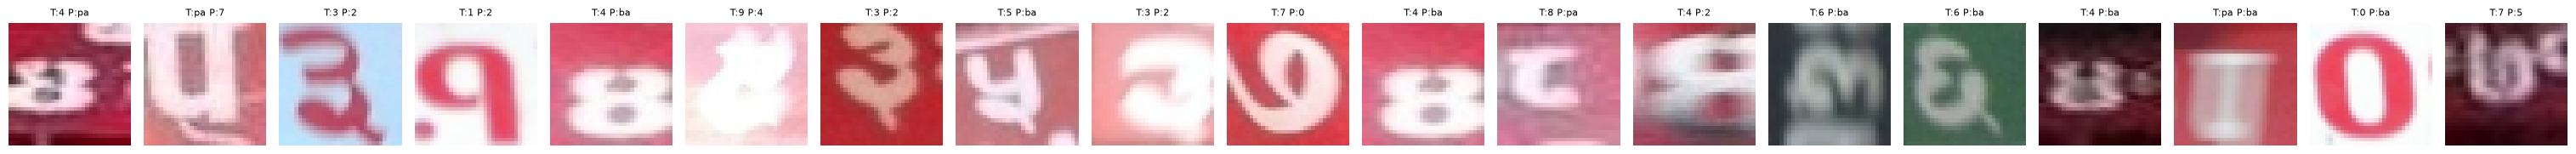

In [29]:
wrong = np.where(y_pred != y_test)[0]
print(f"{len(wrong)} of {len(y_test)} test images misclassified")

fig, axes = plt.subplots(1, len(wrong), figsize=(1.6 * len(wrong), 2.2))

for ax, i in zip(np.atleast_1d(axes), wrong):
    ax.imshow(X_test[i])
    ax.set_title(f"T:{class_names[y_test[i]]} P:{class_names[y_pred[i]]}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()